# FruitSeg30 Dataset Preprocessor
Converts the raw FruitSeg30 dataset into a clean structure:
- `FruitSeg30_processed/images/` — all images renamed consistently
- `FruitSeg30_processed/masks/` — corresponding colorized masks (same filename)
- `FruitSeg30_processed/class_dict.csv` — RGB color mapping per class

**Structure confirmed:**
```
FruitSeg30/
  Apple_Gala/
    Images/   1.jpg  2.jpg  10.jpg  ...
    Mask/     1_mask.png  2_mask.png  10_mask.png  ...
```
Pairing key = the leading number: `1.jpg` <-> `1_mask.png`

**GPU:** NOT needed — keep it off.

In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import csv, random
from pathlib import Path
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
print('All imports OK')

All imports OK


In [2]:
# ── Cell 2: Classes + colors ──────────────────────────────────────────────────
ALL_CLASSES = [
    'Apple_Gala', 'Apple_Golden Delicious', 'Avocado', 'Banana', 'Berry',
    'Burmese Grape', 'Carambola', 'Date Palm', 'Dragon', 'Elephant Apple',
    'Grape', 'Green Coconut', 'Guava', 'Hog Plum', 'Kiwi', 'Lichi',
    'Malta', 'Mango Golden Queen', 'Mango_Alphonso', 'Mango_Amrapali',
    'Mango_Bari', 'Mango_Himsagar', 'Olive', 'Orange', 'Palm',
    'Persimmon', 'Pineapple', 'Pomegranate', 'Watermelon', 'White Pear',
]

CLASS_COLORS = [
    (192,   0,   0),  # Apple_Gala
    (192,  64,   0),  # Apple_Golden Delicious
    ( 64, 128,   0),  # Avocado
    (192, 192,   0),  # Banana
    (128,   0, 128),  # Berry
    ( 64,   0,  64),  # Burmese Grape
    (192, 128,   0),  # Carambola
    (128,  64,   0),  # Date Palm
    (192,   0, 128),  # Dragon
    (  0, 192,  64),  # Elephant Apple
    ( 64,   0, 192),  # Grape
    (  0, 192,   0),  # Green Coconut
    (128, 192,   0),  # Guava
    (192,  64,  64),  # Hog Plum
    ( 64, 128,  64),  # Kiwi
    (192,   0,  64),  # Lichi
    (192,  64, 128),  # Malta
    (192, 128,  64),  # Mango Golden Queen
    (192, 192,  64),  # Mango_Alphonso
    (128, 192,  64),  # Mango_Amrapali
    ( 64, 192,   0),  # Mango_Bari
    (  0, 192, 128),  # Mango_Himsagar
    ( 64,  64,  64),  # Olive
    (192,  96,   0),  # Orange
    (128, 128,   0),  # Palm
    (192,   0, 192),  # Persimmon
    (255, 165,   0),  # Pineapple
    (128,   0,   0),  # Pomegranate
    (  0, 128, 192),  # Watermelon
    (200, 200, 200),  # White Pear
]

assert len(ALL_CLASSES) == 30 and len(CLASS_COLORS) == 30
CLASS_TO_COLOR = dict(zip(ALL_CLASSES, CLASS_COLORS))
print('30 classes and 30 colors loaded ✓')

30 classes and 30 colors loaded ✓


In [3]:
# ── Cell 3: Locate dataset root ───────────────────────────────────────────────
def find_root():
    candidates = [
        Path('/kaggle/input/datasets/mohuaakter/fruitseg30-dataset/FruitSeg30'),
        Path('/kaggle/input/fruitseg30-dataset/FruitSeg30'),
        Path('/kaggle/input/fruitseg30/FruitSeg30'),
    ]
    for p in candidates:
        if p.exists() and sum((p / c).exists() for c in ALL_CLASSES) >= 5:
            return p
    for hit in Path('/kaggle/input').rglob('Apple_Gala'):
        return hit.parent
    raise FileNotFoundError('Dataset not found. Add mohuaakter/fruitseg30-dataset via Add Data.')

ROOT = find_root()
print('Dataset root:', ROOT)
missing = [c for c in ALL_CLASSES if not (ROOT / c).exists()]
print(f'Missing folders: {missing}' if missing else 'All 30 class folders found ✓')

Dataset root: /kaggle/input/datasets/mohuaakter/fruitseg30-dataset/FruitSeg30
All 30 class folders found ✓


In [4]:
# ── Cell 4: Inspect one class folder ─────────────────────────────────────────
sample_cls = ALL_CLASSES[0]
sample_dir = ROOT / sample_cls
print(f'Contents of "{sample_cls}":')
for sub in sorted(sample_dir.iterdir()):
    if sub.is_dir():
        files = sorted(sub.iterdir())[:6]
        total = len(list(sub.iterdir()))
        print(f'  [DIR] {sub.name}/  ({total} files)')
        for f in files:
            print(f'        {f.name}')
        if total > 6:
            print(f'        ... and {total - 6} more')

Contents of "Apple_Gala":
  [DIR] Images/  (65 files)
        1.jpg
        10.jpg
        11.jpg
        12.jpg
        13.jpg
        14.jpg
        ... and 59 more
  [DIR] Mask/  (65 files)
        10_mask.png
        11_mask.png
        12_mask.png
        13_mask.png
        14_mask.png
        15_mask.png
        ... and 59 more


In [5]:
# ── Cell 5: Image-mask pairing ────────────────────────────────────────────────
#
# Images/  -> 1.jpg   2.jpg   10.jpg  ...   stem = "1", "2", "10"
# Mask/    -> 1_mask.png  2_mask.png  ...   stem = "1_mask", "2_mask"
#
# Strategy: strip everything after the first "_" to get the numeric key.
#   "1_mask"  -> "1"
#   "10_mask" -> "10"
#   "1"       -> "1"   (image stem is already just the number)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def numeric_key(stem: str) -> str:
    """'10_mask' -> '10',  '10' -> '10'"""
    return stem.split('_')[0]

def find_image_mask_pairs(class_dir: Path):
    IMG_NAMES  = {'images', 'image', 'img', 'imgs', 'original', 'rgb', 'photo'}
    MASK_NAMES = {'mask', 'masks', 'label', 'labels', 'gt', 'annotation', 'seg'}

    # Case-insensitive sub-folder match
    subdirs  = {d.name.lower(): d for d in class_dir.iterdir() if d.is_dir()}
    img_dir  = next((subdirs[k] for k in IMG_NAMES  if k in subdirs), None)
    mask_dir = next((subdirs[k] for k in MASK_NAMES if k in subdirs), None)

    if not img_dir or not mask_dir:
        print(f'  ✗ Missing sub-folders in {class_dir.name}: found {list(subdirs.keys())}')
        return []

    # Build lookup by numeric key
    imgs  = {numeric_key(f.stem): f
             for f in img_dir.iterdir()  if f.suffix.lower() in IMG_EXTS}
    masks = {numeric_key(f.stem): f
             for f in mask_dir.iterdir() if f.suffix.lower() in IMG_EXTS}

    common = sorted(set(imgs) & set(masks),
                    key=lambda x: int(x) if x.isdigit() else x)

    # Report any unpaired files
    only_imgs  = set(imgs)  - set(masks)
    only_masks = set(masks) - set(imgs)
    if only_imgs:  print(f'  ! {class_dir.name}: {len(only_imgs)} images with no mask  (e.g. {sorted(only_imgs, key=lambda x: int(x) if x.isdigit() else x)[:3]})')
    if only_masks: print(f'  ! {class_dir.name}: {len(only_masks)} masks with no image (e.g. {sorted(only_masks, key=lambda x: int(x) if x.isdigit() else x)[:3]})')

    return [(imgs[k], masks[k]) for k in common]


# ── Quick test on Apple_Gala ──
test_pairs = find_image_mask_pairs(ROOT / ALL_CLASSES[0])
print(f'\n{ALL_CLASSES[0]}: {len(test_pairs)} pairs found')
for img_p, msk_p in test_pairs[:4]:
    print(f'  {img_p.name:<12}  <-->  {msk_p.name}')


Apple_Gala: 65 pairs found
  1.jpg         <-->  1_mask.png
  2.jpg         <-->  2_mask.png
  3.jpg         <-->  3_mask.png
  4.jpg         <-->  4_mask.png


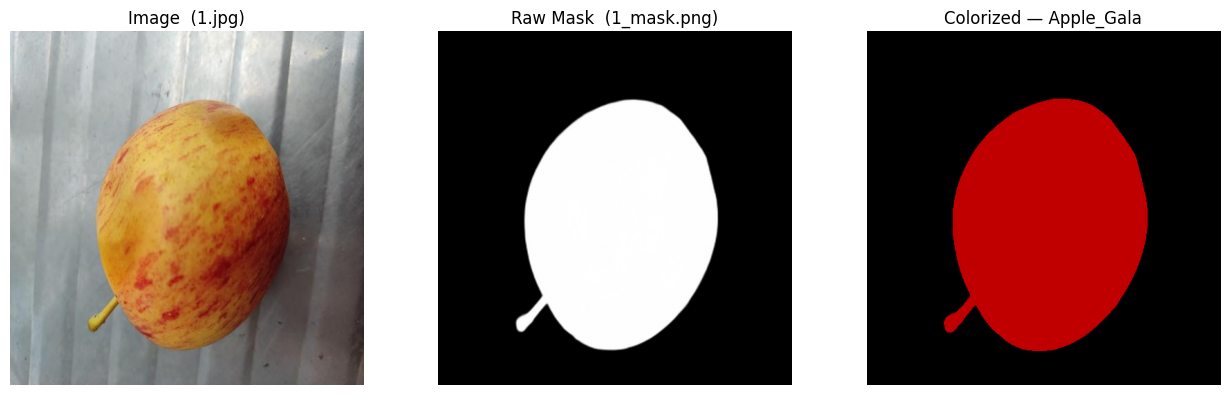

Sanity check passed ✓  If the colorized mask looks right, proceed.


In [6]:
# ── Cell 6: Colorize mask + visual sanity check ───────────────────────────────
def colorize_mask(mask_path: Path, color: tuple) -> np.ndarray:
    """B&W mask -> RGB mask with class color on foreground, black background."""
    mask_np = np.array(Image.open(mask_path).convert('L'))
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    rgb[mask_np > 10] = color
    return rgb

if test_pairs:
    t_img, t_msk = test_pairs[0]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(Image.open(t_img))
    axes[0].set_title(f'Image  ({t_img.name})')
    axes[1].imshow(Image.open(t_msk), cmap='gray')
    axes[1].set_title(f'Raw Mask  ({t_msk.name})')
    axes[2].imshow(colorize_mask(t_msk, CLASS_TO_COLOR[ALL_CLASSES[0]]))
    axes[2].set_title(f'Colorized — {ALL_CLASSES[0]}')
    for ax in axes: ax.axis('off')
    plt.tight_layout(); plt.show()
    print('Sanity check passed ✓  If the colorized mask looks right, proceed.')
else:
    print('No pairs found — check Cell 5 output before continuing.')

In [7]:
# ── Cell 7: Create output directories ─────────────────────────────────────────
OUT_ROOT   = Path('/kaggle/working/FruitSeg30_processed')
OUT_IMAGES = OUT_ROOT / 'images'
OUT_MASKS  = OUT_ROOT / 'masks'
OUT_IMAGES.mkdir(parents=True, exist_ok=True)
OUT_MASKS.mkdir(parents=True, exist_ok=True)
print('Output folders ready:')
print(' ', OUT_IMAGES)
print(' ', OUT_MASKS)

Output folders ready:
  /kaggle/working/FruitSeg30_processed/images
  /kaggle/working/FruitSeg30_processed/masks


In [8]:
# ── Cell 8: Main conversion loop ──────────────────────────────────────────────
#
# Output filename:  {ClassName_safe}_{index:04d}.png
#   image → images/Apple_Gala_0001.png
#   mask  → masks/Apple_Gala_0001.png   ← identical name, different folder

def sanitize(name: str) -> str:
    return name.replace(' ', '_')

STATS         = []
total_written = 0
total_skipped = 0

for cls_name in tqdm(ALL_CLASSES, desc='Classes'):
    class_dir = ROOT / cls_name
    color     = CLASS_TO_COLOR[cls_name]
    safe      = sanitize(cls_name)
    written   = 0

    if not class_dir.exists():
        print(f'  ✗ Folder missing: {cls_name}')
        STATS.append((cls_name, 0)); continue

    pairs = find_image_mask_pairs(class_dir)
    if not pairs:
        print(f'  ✗ No pairs found: {cls_name}')
        STATS.append((cls_name, 0)); continue

    for idx, (img_path, msk_path) in enumerate(tqdm(pairs, desc=safe, leave=False)):
        out_name = f'{safe}_{idx + 1:04d}.png'

        # Save image as RGB PNG
        try:
            Image.open(img_path).convert('RGB').save(OUT_IMAGES / out_name)
        except Exception as e:
            print(f'  ERROR (image) {img_path.name}: {e}')
            total_skipped += 1; continue

        # Save colorized mask
        try:
            Image.fromarray(colorize_mask(msk_path, color)).save(OUT_MASKS / out_name)
        except Exception as e:
            print(f'  ERROR (mask)  {msk_path.name}: {e}')
            (OUT_IMAGES / out_name).unlink(missing_ok=True)  # keep dirs in sync
            total_skipped += 1; continue

        written += 1; total_written += 1

    STATS.append((cls_name, written))

print(f'\n✓ Done.  Written: {total_written} pairs  |  Skipped: {total_skipped}')

Classes:   0%|          | 0/30 [00:00<?, ?it/s]

Apple_Gala:   0%|          | 0/65 [00:00<?, ?it/s]

Apple_Golden_Delicious:   0%|          | 0/57 [00:00<?, ?it/s]

Avocado:   0%|          | 0/72 [00:00<?, ?it/s]

Banana:   0%|          | 0/82 [00:00<?, ?it/s]

...

Pineapple:   0%|          | 0/65 [00:00<?, ?it/s]

Pomegranate:   0%|          | 0/61 [00:00<?, ?it/s]

Watermelon:   0%|          | 0/42 [00:00<?, ?it/s]

White_Pear:   0%|          | 0/41 [00:00<?, ?it/s]


✓ Done.  Written: 1969 pairs  |  Skipped: 0


In [9]:
# ── Cell 9: Generate class_dict.csv ───────────────────────────────────────────
CSV_PATH = OUT_ROOT / 'class_dict.csv'
with open(CSV_PATH, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['name', 'r', 'g', 'b'])
    writer.writerow(['Background', 0, 0, 0])   # class 0
    for cls_name, color in zip(ALL_CLASSES, CLASS_COLORS):
        writer.writerow([cls_name, *color])

df = pd.read_csv(CSV_PATH)
print(df.to_string(index=False))
print(f'\nSaved → {CSV_PATH}')

                  name   r   g   b
            Background   0   0   0
            Apple_Gala 192   0   0
Apple_Golden Delicious 192  64   0
               Avocado  64 128   0
                Banana 192 192   0
                 Berry 128   0 128
         Burmese Grape  64   0  64
             Carambola 192 128   0
             Date Palm 128  64   0
                Dragon 192   0 128
        Elephant Apple   0 192  64
                 Grape  64   0 192
         Green Coconut   0 192   0
                 Guava 128 192   0
              Hog Plum 192  64  64
                  Kiwi  64 128  64
                 Lichi 192   0  64
                 Malta 192  64 128
    Mango Golden Queen 192 128  64
        Mango_Alphonso 192 192  64
        Mango_Amrapali 128 192  64
            Mango_Bari  64 192   0
        Mango_Himsagar   0 192 128
                 Olive  64  64  64
                Orange 192  96   0
                  Palm 128 128   0
             Persimmon 192   0 192
             Pineapp

In [10]:
# ── Cell 10: Verify output ────────────────────────────────────────────────────
img_stems  = {p.stem for p in OUT_IMAGES.glob('*.png')}
mask_stems = {p.stem for p in OUT_MASKS.glob('*.png')}

print(f'images/ : {len(img_stems):,} files')
print(f'masks/  : {len(mask_stems):,} files')

orphan_imgs  = img_stems - mask_stems
orphan_masks = mask_stems - img_stems
if orphan_imgs:  print(f'  ✗ {len(orphan_imgs)} images without a mask')
if orphan_masks: print(f'  ✗ {len(orphan_masks)} masks without an image')
if not orphan_imgs and not orphan_masks:
    print('  ✓ All image-mask pairs are perfectly matched')

print('\nPer-class breakdown:')
for cls_name, cnt in STATS:
    mark = '✓' if cnt > 0 else '✗'
    print(f'  {mark} {cls_name:<30} {cnt:>4} pairs')

images/ : 1,969 files
masks/  : 1,969 files
  ✓ All image-mask pairs are perfectly matched

Per-class breakdown:
  ✓ Apple_Gala                       65 pairs
  ✓ Apple_Golden Delicious           57 pairs
  ✓ Avocado                          72 pairs
  ✓ Banana                           82 pairs
  ✓ Berry                            62 pairs
  ✓ Burmese Grape                    78 pairs
  ✓ Carambola                       100 pairs
  ✓ Date Palm                       147 pairs
  ✓ Dragon                           96 pairs
  ✓ Elephant Apple                   81 pairs
  ✓ Grape                            82 pairs
  ✓ Green Coconut                    37 pairs
  ✓ Guava                            55 pairs
  ✓ Hog Plum                         91 pairs
  ✓ Kiwi                             61 pairs
  ✓ Lichi                            48 pairs
  ✓ Malta                            50 pairs
  ✓ Mango Golden Queen               16 pairs
  ✓ Mango_Alphonso                   45 pairs
  ✓ Mango_Amr

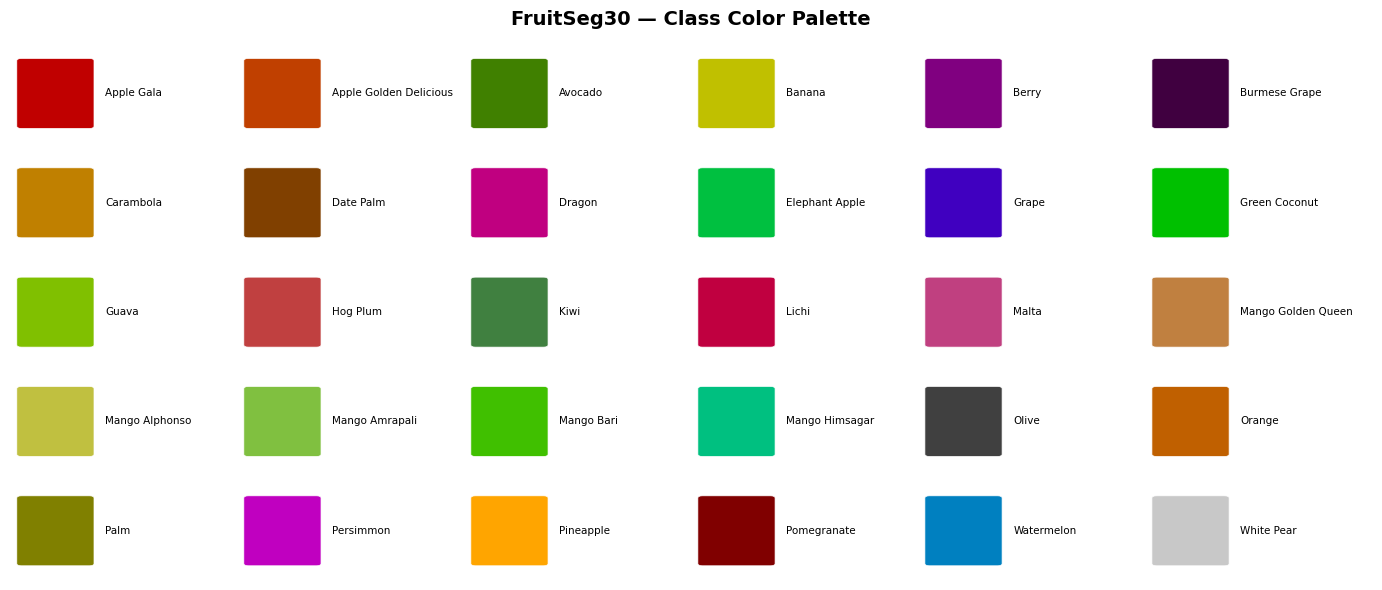

Saved → color_palette.png


In [11]:
# ── Cell 11: Color palette ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 6); ax.set_ylim(0, 5); ax.axis('off')
ax.set_title('FruitSeg30 — Class Color Palette', fontsize=14, fontweight='bold')
for i, (cls, color) in enumerate(zip(ALL_CLASSES, CLASS_COLORS)):
    col = i % 6; row = i // 6
    x = col + 0.05; y = 4.5 - row
    norm = tuple(c / 255 for c in color)
    rect = mpatches.FancyBboxPatch((x, y - 0.35), 0.3, 0.6,
                                    boxstyle='round,pad=0.02',
                                    facecolor=norm, edgecolor='white', linewidth=0.5)
    ax.add_patch(rect)
    ax.text(x + 0.37, y - 0.05, cls.replace('_', ' '), fontsize=7.5, va='center')
plt.tight_layout()
plt.savefig(OUT_ROOT / 'color_palette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → color_palette.png')

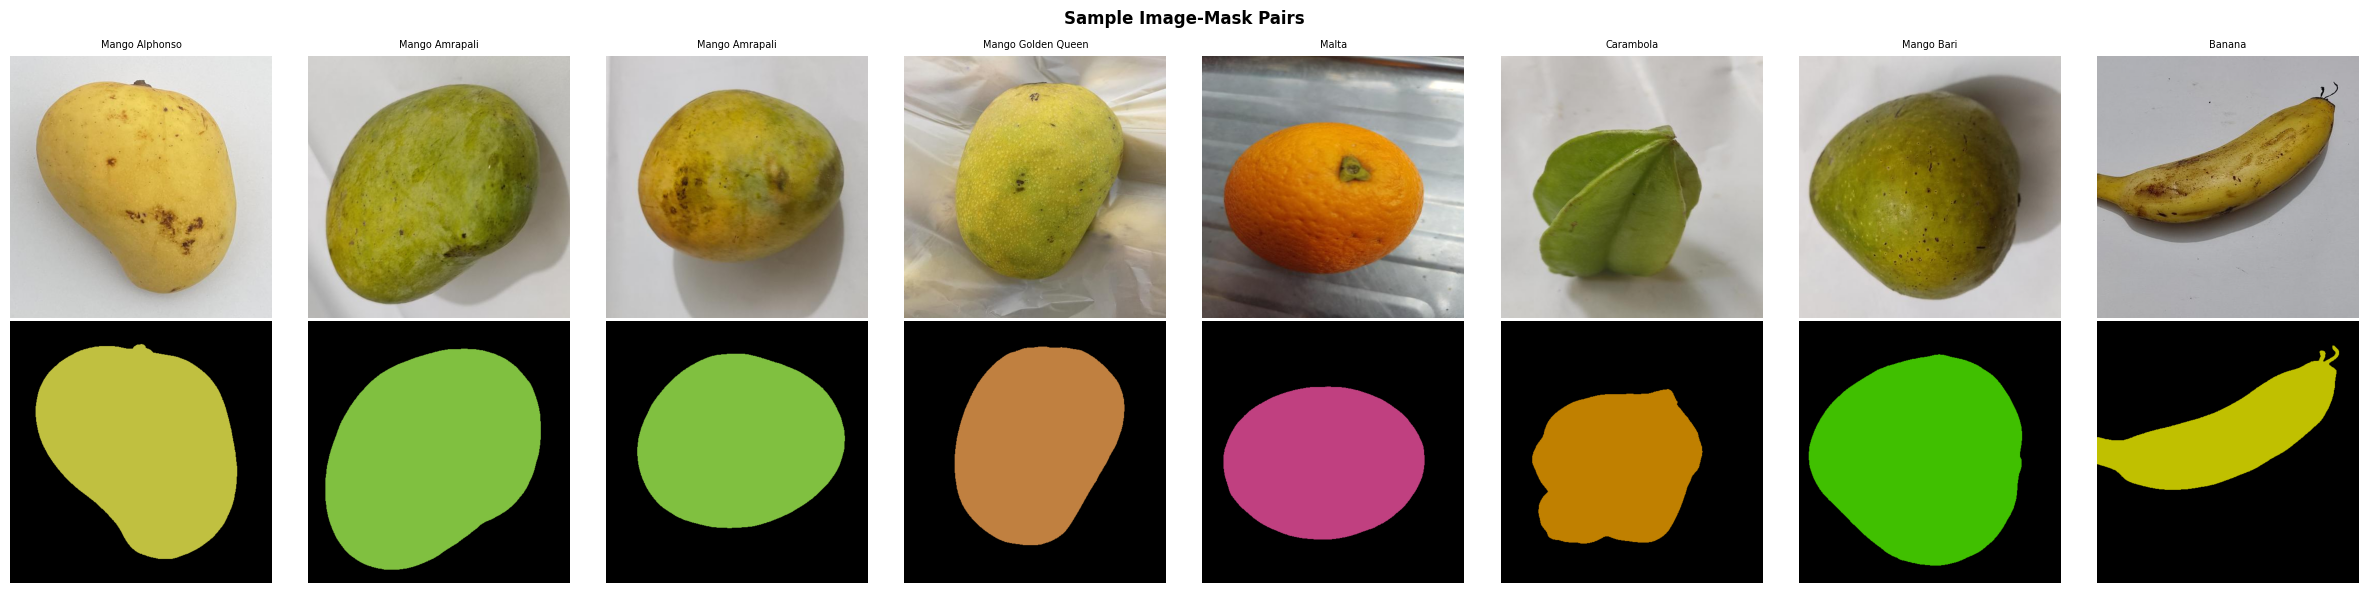

In [12]:
# ── Cell 12: Sample image-mask grid ───────────────────────────────────────────
if img_stems:
    n_show       = min(8, len(img_stems))
    sample_stems = random.sample(sorted(img_stems), n_show)
    fig, axes    = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
    if n_show == 1:
        axes = np.array(axes).reshape(2, 1)
    for col, stem in enumerate(sample_stems):
        axes[0][col].imshow(np.array(Image.open(OUT_IMAGES / f'{stem}.png')))
        axes[1][col].imshow(np.array(Image.open(OUT_MASKS  / f'{stem}.png')))
        for row in range(2): axes[row][col].axis('off')
        label = '_'.join(stem.split('_')[:-1]).replace('_', ' ')
        axes[0][col].set_title(label, fontsize=7)
    axes[0][0].set_ylabel('Image', fontsize=9)
    axes[1][0].set_ylabel('Mask',  fontsize=9)
    plt.suptitle('Sample Image-Mask Pairs', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('No files written — check earlier cells for errors.')

In [13]:
# ── Cell 13: Final summary + zip command ──────────────────────────────────────
print('=' * 55)
print('FINAL OUTPUT SUMMARY')
print('=' * 55)
print(f'  Root           : {OUT_ROOT}')
print(f'  images/        : {len(img_stems):,} PNG files')
print(f'  masks/         : {len(mask_stems):,} PNG files (colorized)')
print(f'  class_dict.csv : 31 rows (30 classes + background)')
print('=' * 55)
print()
print('To zip for download, run this in a new cell:')
print('  !zip -r /kaggle/working/FruitSeg30_processed.zip /kaggle/working/FruitSeg30_processed/')

FINAL OUTPUT SUMMARY
  Root           : /kaggle/working/FruitSeg30_processed
  images/        : 1,969 PNG files
  masks/         : 1,969 PNG files (colorized)
  class_dict.csv : 31 rows (30 classes + background)

To zip for download, run this in a new cell:
  !zip -r /kaggle/working/FruitSeg30_processed.zip /kaggle/working/FruitSeg30_processed/
